# Nighttime lights — Mumbai replication (paper example)

**This notebook uses two kernels, bridged by Google Drive**.

1. **Part 1 (Python)** mounts Drive, then downloads the monthly SL-corrected
   VIIRS rasters for a bounding box around Mumbai from Google Earth Engine
   straight into a Drive folder, using the same `Export.image.toDrive`
   pattern as `nighttime_lights.ipynb`.
2. You **change the Colab runtime to Julia** at the banner. Colab clears
   `/content` on a runtime switch — but **Google Drive is mounted storage,
   so the rasters survive**.
3. **Part 2 (Julia)** reads the rasters straight from the mounted Drive and
   replicates the Mumbai example from the paper: Table 1 (raw vs. cleaned
   summary statistics), Table 2 (unused, raw radiance vs. cloud-free-observation 
   summary statistics), and Figure 1 (aggregate raw vs. cleaned radiance
   over time), using `NighttimeLights.clean_complete`.

Output: `table1.csv`, `table2.csv`, and `raw_vs_cleaned.png` in
*My Drive / `NighttimeLights-Mumbai-Replication`*.


---
# Part 1 · Python — download VIIRS rasters for Mumbai

Run with the default **Python 3** runtime.


## 1 · Mount Drive + Earth Engine

In [ ]:
from google.colab import drive
drive.mount("/content/drive")          # <- the bridge across the kernel switch

import ee
ee.Authenticate()

PROJECT = "PROJECT-ID-HERE"             # <-- your GEE Cloud project id
ee.Initialize(project=PROJECT)
print("Drive mounted, Earth Engine ready.")

Mounted at /content/drive
Drive mounted, Earth Engine ready.


## 2 · Parameters

`VIIRS_COLL` is the stray-light-corrected ("sl") monthly product — the same
one `SRC/replication.jl` reads, here pulled straight from Earth Engine.


In [ ]:
START = (2014, 1)            # first (year, month), inclusive
END   = (2018, 1)            # last  (year, month), inclusive


DRIVE_FOLDER   = "NighttimeLights-Mumbai-Replication"   # change as needed
VIIRS_COLL     = "NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG"   # stray-light-corrected composite


## 3 · Export region (bounding box around Mumbai)

In [3]:
# lat/lon box around Mumbai
LON_MIN, LON_MAX = 72.721252, 73.074187
LAT_MIN, LAT_MAX = 18.849475, 19.49907

region = ee.Geometry.Rectangle([LON_MIN, LAT_MIN, LON_MAX, LAT_MAX])
print("export region ready:", region.getInfo()["coordinates"])

export region ready: [[[72.721252, 18.849475], [73.074187, 18.849475], [73.074187, 19.49907], [72.721252, 19.49907], [72.721252, 18.849475]]]


## 4 · Download one 2-band GeoTIFF per month → Drive

One `Export.image.toDrive` task per month — each writes a 2-band GeoTIFF
(band 1 `avg_rad`, band 2 `cf_cvg`; `clean_complete` needs both) to the
Drive folder. The cell queues all tasks first, then waits on them with a
single progress bar that prints each task's state every 30 s. Already-present
TIFs on Drive are skipped so the cell is resumable.


In [4]:
import os, time
from collections import Counter
from tqdm.auto import tqdm


def months(start, end):
    y, m = start
    while (y, m) <= end:
        yield y, m
        m += 1
        if m == 13:
            m, y = 1, y + 1


drive_dir = f"/content/drive/MyDrive/{DRIVE_FOLDER}"
os.makedirs(drive_dir, exist_ok=True)
have = set(os.listdir(drive_dir))

native_proj = ee.ImageCollection(VIIRS_COLL).first().select("avg_rad").projection().getInfo()
export_crs = native_proj["crs"]
export_crs_transform = native_proj["transform"]

# Queue one Export.toDrive task per month not already on Drive.
tasks = {}
for y, m in months(START, END):
    desc = f"viirs_{y}_{m:02d}"
    if f"{desc}.tif" in have:
        continue
    start = ee.Date.fromYMD(y, m, 1)
    img = (ee.ImageCollection(VIIRS_COLL)
           .filterDate(start, start.advance(1, "month"))
           .select(["avg_rad", "cf_cvg"])
           .first())
    if img is None:
        print(f"  no image for {desc}, skipping")
        continue
    t = ee.batch.Export.image.toDrive(
        image=ee.Image(img).toFloat(), description=desc,
        folder=DRIVE_FOLDER, fileNamePrefix=desc, region=region,
          crs=export_crs, crsTransform=export_crs_transform,
          maxPixels=1e13)
    t.start()
    tasks[desc] = t

print(f"{len(tasks)} task(s) queued.  {len(have)} already on Drive.")

# Wait for every task to reach a terminal state.
# The postfix shows live per-state counts (ready, running, succeeded, …) so
# progress is visible even before the first task completes.
TERM = ("COMPLETED", "SUCCEEDED", "FAILED", "CANCELLED")
done = set()
with tqdm(total=len(tasks), desc="exports") as bar:
    while len(done) < len(tasks):
        states = Counter()
        for desc, t in tasks.items():
            if desc in done:
                continue
            try:
                st = t.status()["state"]
            except Exception as e:
                bar.write(f"  {desc}: status() error — {type(e).__name__}: {e}")
                continue
            states[st.lower()] += 1
            if st in TERM:
                done.add(desc)
                bar.update(1)
                if st not in ("COMPLETED", "SUCCEEDED"):
                    bar.write(f"  ⚠ {desc}: {st}")
        bar.set_postfix(dict(states))     # live per-state counts
        if len(done) < len(tasks):
            time.sleep(30)

print(f"done -> {drive_dir}")

0 task(s) queued.  52 already on Drive.


exports: 0it [00:00, ?it/s]

done -> /content/drive/MyDrive/NighttimeLights-Mumbai-Replication


---
# ⚠️  SWITCH THE COLAB RUNTIME TO JULIA NOW

**Runtime → Change runtime type → "Julia". 

Tested using Julia 1.12.

Colab clears `/content` on the switch, **but Google Drive is mounted
storage** — the VIIRS rasters Part 1 wrote are still in
*My Drive / `NighttimeLights-Mumbai-Replication`*. Part 2 reads them straight
from there.

If Drive isn't visible after the switch, mount it from the Colab file
browser (folder icon in the sidebar → "Mount Drive").

---
# Part 2 · Julia replicate Tables/Figures


## 5 · Install Julia packages

In [ ]:
using Pkg

# ───── Packages (no-ops after the depot extract; otherwise full install) ─
Pkg.add(["Rasters", "DataFrames", "CSV", "Dates", "Statistics",
         "Plots", "Unitful", "LaTeXStrings", "Printf", "NighttimeLights"])
# Pkg.add(url="https://github.com/xKDR/NighttimeLights.jl")

using Rasters, NighttimeLights, Dates, Unitful, LaTeXStrings, Statistics,
      DataFrames, Printf, CSV, Plots
println("Julia packages ready")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed LERC_jll ───────────────── v4.2.0+0
   Installed NNlib ──────────────────── v0.9.45
   Installed ImageIO ────────────────── v0.6.10
   Installed Unitful ────────────────── v1.29.0
   Installed GR ─────────────────────── v0.73.27
   Installed GR_jll ─────────────────── v0.73.27+0
   Installed aws_c_auth_jll ─────────── v0.9.6+0
   Installed GDAL_jll ───────────────── v304.1200.400+0
   Installed LRUCache ───────────────── v1.6.2
   Installed InlineStrings ──────────── v1.4.6
   Installed DimensionalData ────────── v0.30.2
   Installed StaticArrays ───────────── v1.9.20
   Installed Roots ──────────────────── v3.0.8
   Installed aws_c_sdkutils_jll ─────── v0.2.4+1
   Installed Statistics ─────────────── v1.11.5
   Installed Qhull_jll ──────────────── v10008.0.1004+0
   Installed muparser_jll ───────────── v2.3.5+0
   Installed GLM ────────────────────── v1.9.5
   Installed DBFTables 

Julia packages ready


  24738.9 ms  ✓ Lux → ReactantExt
  403 dependencies successfully precompiled in 2261 seconds. 177 already precompiled.


## 6 · Point at the Drive folder

The Drive mount persists across kernels in a Colab session, so
`/content/drive/MyDrive/<folder>` is simply there after the runtime switch.


In [ ]:
const DRIVE_FOLDER = "NighttimeLights-Mumbai-Replication" # same as in Python code above
const RASTER_DIR    = joinpath("/content/drive/MyDrive", DRIVE_FOLDER)
const OUT_TABLE_RAW_VS_CFOBS = joinpath(RASTER_DIR, "table1.csv")
const OUT_TABLE_RAW_VS_CLEANED = joinpath(RASTER_DIR, "table2.csv")
const OUT_FIGURE_RAW_VS_CLEANED = joinpath(RASTER_DIR, "raw_vs_cleaned.png")
@assert isdir(RASTER_DIR) "Drive not visible - mount it via the file browser"
println("raster dir: ", RASTER_DIR)

raster dir: /content/drive/MyDrive/NighttimeLights-Mumbai-Replication


## 7 · Load the monthly TIFs into datacubes

Each GeoTIFF has 2 bands — band 1 `avg_rad`, band 2 `cf_cvg`. Each slice is
materialised with `read()` so the combined cube is a plain in-memory array.

In [3]:
# Pattern-match upfront so stray files (.gstmp, shortcuts, etc.) are skipped.
const VIIRS_RX = r"^viirs_(\d{4})_(\d{2})\.tif$"
files = sort(filter(f -> occursin(VIIRS_RX, f), readdir(RASTER_DIR)))
isempty(files) && error("no VIIRS TIFs in $RASTER_DIR - did Part 1 finish?")

function tdate(f)
    m = match(VIIRS_RX, f)
    Date(parse(Int, m[1]), parse(Int, m[2]))
end
dates = tdate.(files)

# Ti index must stay numeric (not Date) because Ti(At(201409))-style lookups
# in section 8 need it.
timestamps = parse.(Int, NighttimeLights.yearmon.(dates))

rad = [read(Raster(joinpath(RASTER_DIR, f); lazy=true))[Band=1] for f in files]
cf  = [read(Raster(joinpath(RASTER_DIR, f); lazy=true))[Band=2] for f in files]

mumbai_radiance    = Rasters.combine(RasterSeries(rad, Ti(timestamps)), Ti)
mumbai_n_cloudfree = Rasters.combine(RasterSeries(cf,  Ti(timestamps)), Ti)
println("radiance cube: ", size(mumbai_radiance), "  (", length(files), " months)")

radiance cube: (86, 157, 49)  (49 months)


## 8 · Confirm data in paper

The share of pixels missing cloud-free observations in a monsoon month, and
the share of physically-invalid negative radiance values.


In [4]:
no_pixel = size(mumbai_radiance)[1] * size(mumbai_radiance)[2] # pixels per monthly slice

# Share of pixels with zero cloud-free observations in August 2014 (a monsoon month)
percentage_missing_aug2014 = count(i -> i == 0, view(mumbai_n_cloudfree, Ti(At(201408)))) / no_pixel * 100
println("Percentage of missing values in August 2014: ", percentage_missing_aug2014, "%")

# Share of pixels with negative (physically invalid) radiance in December 2014
percentage_negative_nov2014 = count(i -> i < 0, view(mumbai_radiance, Ti(At(201411)))) / no_pixel * 100
println("Percentage of negative values in Nov 2014: ", percentage_negative_nov2014, "%")

Percentage of missing values in August 2014: 48.14101614575618%
Percentage of negative values in Nov 2014: 0.8221004295659902%


## 9 · Clean with `NighttimeLights.clean_complete`

Runs the full PSTT2021 pipeline (NA recoding, background-noise masking,
stable-pixel detection, Hampel outlier removal, cloud-bias correction,
interpolation) over the Mumbai cube — the same call used in the paper's
usage example.


In [5]:
mumbai_cleaned = clean_complete(mumbai_radiance, mumbai_n_cloudfree, bgthreshold=4)
mumbai_cleaned = Float32.(mumbai_cleaned)
println("cleaned cube: ", size(mumbai_cleaned))

cleaned cube: (86, 157, 49)


## 10 · Background noise: worst-case bound vs. what's actually left

`bgnoise_PSTT2021` returns a spatial `(x, y)` mask, not a per-month one — it's
built once from the annual weighted-average radiance. Dark/noise pixels come
back as missing and lit pixels as 1 — `apply_mask` (`mask .* data`) then
zeroes every month of a noise pixel's time series directly.

Worst case: assume every noise pixel sat right at the 4.0 threshold in every
one of the months: an upper bound, since a pixel classified as noise from
its *annual* average could still spike above 4 in individual months. Compare
that bound against the total radiance actually left after cleaning.


In [6]:
noise_mask = bgnoise_PSTT2021(mumbai_radiance, mumbai_n_cloudfree, 4)
n_noise_pixels = count(ismissing, noise_mask) # pixels the pipeline masks out as noise

worst_case_noise_inflation = n_noise_pixels * 4 * length(files) # upper bound over the whole window
total_radiance_cleaned = sum(mumbai_cleaned) # what's actually left after the full cleaning pipeline


println("Background-noise pixels masked: ", n_noise_pixels, " / ", no_pixel)
println("Worst-case noise inflation (n_noise_pixels * 4 * ", length(files), " months): ", worst_case_noise_inflation)
println("Total cleaned radiance (summed over all pixels and months): ", total_radiance_cleaned)
println("Worst-case noise inflation as % of cleaned total: ", round(worst_case_noise_inflation / total_radiance_cleaned * 100, sigdigits = 3), "%")

Background-noise pixels masked: 7340 / 13502
Worst-case noise inflation (n_noise_pixels * 4 * 49 months): 1438640
Total cleaned radiance (summed over all pixels and months): 6.0159545e6
Worst-case noise inflation as % of cleaned total: 23.9%


## 11 · Table 1 — raw radiance vs. cloud-free-observation summary statistics


In [7]:
function sumstats(x) # five-number-ish summary used to populate Tables 1 and 2
   return round.([minimum(x), mean(x), median(x), quantile(vec(x), 0.99), maximum(x)], sigdigits = 2)
end

missing_percentage = count(i -> i == 0, mumbai_n_cloudfree) / no_pixel / length(files) * 100 # averaged over all months

mumbai_raw_vs_cfobs_table = DataFrame(
    stat = ["Minimum", "Mean", "Median", "99th Percentile", "Maximum", "Missing (%)", "Number of measurements"],
    Radiance = [sumstats(mumbai_radiance)..., missing_percentage, size(mumbai_radiance)],
    cfobs = [sumstats(mumbai_n_cloudfree)..., 0, size(mumbai_n_cloudfree)],
)
CSV.write(OUT_TABLE_RAW_VS_CFOBS, mumbai_raw_vs_cfobs_table)
println("Table 1:")
mumbai_raw_vs_cfobs_table

Table 1:


Row,stat,Radiance,cfobs
,String,Any,Any
1,Minimum,-0.14,0.0
2,Mean,9.1,11.0
3,Median,3.2,12.0
4,99th Percentile,54.0,18.0
5,Maximum,4300.0,19.0
6,Missing (%),2.27495,0
7,Number of measurements,"(86, 157, 49)","(86, 157, 49)"


## 12 · Table 2 — raw vs. cleaned radiance summary statistics


In [8]:
mumbai_raw_vs_cleaned_table = DataFrame(stat = ["Minimum", "Mean", "Median", "99th Percentile", "Maximum"], Raw = sumstats(mumbai_radiance), Cleaned = sumstats(mumbai_cleaned))
CSV.write(OUT_TABLE_RAW_VS_CLEANED, mumbai_raw_vs_cleaned_table)
println("Table 2:")
mumbai_raw_vs_cleaned_table

Table 2:


Row,stat,Raw,Cleaned
,String,Float64,Float64
1,Minimum,-0.14,0.0
2,Mean,9.1,9.1
3,Median,3.2,0.0
4,99th Percentile,54.0,59.0
5,Maximum,4300.0,1700.0


## 13 · Figure: aggregate raw vs. cleaned radiance over time


Minimum of aggregate_radiance_raw: 39013.74
Maximum of aggregate_radiance_raw: 158484.78


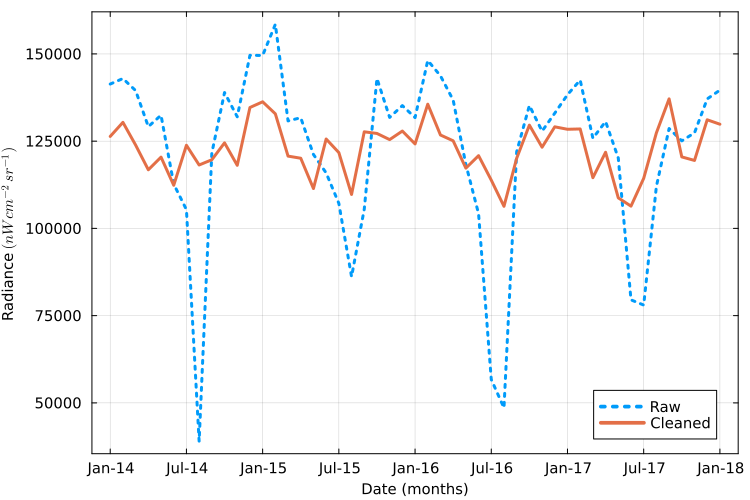

In [9]:
tick_dates = Dates.format.(dates, "u-yy") # x-axis tick labels
Plots.scalefontsizes(1.2)

aggregate_radiance_raw = vcat(sum(sum(mumbai_radiance, dims = 1), dims = 2)...) # sum over (x, y), leaving one value per month
aggregate_radiance_cleaned = vcat(sum(sum(mumbai_cleaned, dims = 1), dims = 2)...)

n = length(files)
fig = plot(1:n, aggregate_radiance_raw, label = "Raw", size = (750, 500), lw = 3,
    legend = :bottomright, framestyle = :box, xtick = (1:6:n, tick_dates[1:6:n]),
    xguidefontsize = 10, yguidefontsize = 10,
    yformatter = y -> @sprintf("%.0f", y), line = :dot)

xlabel!(fig, "Date (months)")
ylabel!(fig, "Radiance " * L"(nW\, cm^{-2}\, sr^{-1})")
plot!(fig, 1:n, aggregate_radiance_cleaned, label = "Cleaned", lw = 3)

println("Minimum of aggregate_radiance_raw: ", minimum(aggregate_radiance_raw))
println("Maximum of aggregate_radiance_raw: ", maximum(aggregate_radiance_raw))

savefig(fig, OUT_FIGURE_RAW_VS_CLEANED)
fig

## 14 · Confirm outputs on Drive


In [10]:
for f in (OUT_TABLE_RAW_VS_CFOBS, OUT_TABLE_RAW_VS_CLEANED, OUT_FIGURE_RAW_VS_CLEANED)
    println(isfile(f) ? "✓ " : "✗ MISSING ", f)
end
println("(all in My Drive / ", DRIVE_FOLDER, ")")

✓ /content/drive/MyDrive/NighttimeLights-Mumbai-Replication/table1.csv
✓ /content/drive/MyDrive/NighttimeLights-Mumbai-Replication/table2.csv
✓ /content/drive/MyDrive/NighttimeLights-Mumbai-Replication/raw_vs_cleaned.png
(all in My Drive / NighttimeLights-Mumbai-Replication)
